In [ ]:
CFG = {
    "scene":        "courthouse",
    "image_folder": None,
    "video_path":   None,
    "fps":          10,
    "max_frames":   None,
    "stride":       None,

    "checkpoint":   "lingbot-map.pt",
    "image_size":   518,
    "patch_size":   14,
    "use_sdpa":     True,

    "mode":                  "streaming",
    "num_scale_frames":      None,
    "keyframe_interval":     None,
    "kv_cache_sliding_window": 64,
    "camera_num_iterations": None,
    "offload_to_cpu":        True,
    "window_size":           128,
    "overlap_keyframes":     8,

    "conf_percentile":  55.0,
    "pixel_stride":     2,
    "max_plot_points":  60000,
    "export_ply":       True,
    "export_glb":       False,
    "launch_viser":     False,

    "run_ablation":     False,
    "seed":             0,
}

WORK = "/content"
REPO = f"{WORK}/lingbot-map"
OUT  = f"{WORK}/lingbot_out"

import os, sys, subprocess, glob, json, time, math, shutil, textwrap

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
os.makedirs(OUT, exist_ok=True)

def sh(cmd, check=True):
    p = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if p.returncode != 0 and check:
        print(p.stdout[-3000:]); print(p.stderr[-3000:])
        raise RuntimeError(f"command failed: {cmd}")
    return p

def probe_gpu():
    try:
        q = sh("nvidia-smi --query-gpu=name,memory.total --format=csv,noheader", check=False)
        if q.returncode != 0 or not q.stdout.strip():
            return None, 0.0
        name, mem = [x.strip() for x in q.stdout.strip().split("\n")[0].split(",")]
        return name, float(mem.split()[0]) / 1024.0
    except Exception:
        return None, 0.0

GPU_NAME, VRAM_GB = probe_gpu()
print("=" * 78)
print(f"GPU        : {GPU_NAME or 'NONE — enable Runtime > Change runtime type > GPU'}")
print(f"VRAM       : {VRAM_GB:.1f} GB")
try:
    import psutil
    print(f"System RAM : {psutil.virtual_memory().total/2**30:.1f} GB")
except Exception:
    pass
print(f"Free disk  : {shutil.disk_usage(WORK).free/2**30:.1f} GB   (checkpoint is 4.6 GB)")
print("=" * 78)

if GPU_NAME is None:
    raise SystemExit("This model needs a CUDA GPU. Switch the Colab runtime to GPU.")

if VRAM_GB < 18:
    AUTO = dict(max_frames=48, num_scale_frames=4, camera_num_iterations=2, kvsw=48)
    tier = "small (<18 GB)"
elif VRAM_GB < 30:
    AUTO = dict(max_frames=96, num_scale_frames=8, camera_num_iterations=4, kvsw=64)
    tier = "medium (18-30 GB)"
else:
    AUTO = dict(max_frames=240, num_scale_frames=8, camera_num_iterations=4, kvsw=64)
    tier = "large (30+ GB)"

if CFG["max_frames"] is None: CFG["max_frames"] = AUTO["max_frames"]
if CFG["num_scale_frames"] is None: CFG["num_scale_frames"] = AUTO["num_scale_frames"]
if CFG["camera_num_iterations"] is None: CFG["camera_num_iterations"] = AUTO["camera_num_iterations"]
if VRAM_GB < 18: CFG["kv_cache_sliding_window"] = AUTO["kvsw"]

print(f"Auto-tuned for {tier}: max_frames={CFG['max_frames']}, "
      f"scale_frames={CFG['num_scale_frames']}, "
      f"cam_iters={CFG['camera_num_iterations']}, "
      f"kv_window={CFG['kv_cache_sliding_window']}")
print("Raise CFG['max_frames'] if you have headroom — reconstruction quality "
      "improves a lot with more views.\n")

In [ ]:
if not os.path.isdir(REPO):
    print("Cloning repo (shallow) ...")
    sh(f"git clone --depth 1 https://github.com/Robbyant/lingbot-map.git {REPO}")

print("Installing deps ...")
sh("pip install -q einops safetensors huggingface_hub")
sh(f"pip install -q -e {REPO} --no-deps", check=False)
if REPO not in sys.path:
    sys.path.insert(0, REPO)

import importlib
importlib.invalidate_caches()
import cv2, numpy as np
print(f"numpy {np.__version__} | opencv {cv2.__version__}")

from huggingface_hub import hf_hub_download

print(f"\nFetching {CFG['checkpoint']} from robbyant/lingbot-map ...")
t0 = time.time()
CKPT = hf_hub_download(repo_id="robbyant/lingbot-map",
                       filename=CFG["checkpoint"],
                       cache_dir=f"{WORK}/hf_cache")
print(f"  -> {CKPT}  ({os.path.getsize(CKPT)/2**30:.2f} GB, {time.time()-t0:.0f}s)")

In [ ]:
import torch
import matplotlib.pyplot as plt

from lingbot_map.models.gct_stream import GCTStream
from lingbot_map.utils.load_fn import load_and_preprocess_images
from lingbot_map.utils.pose_enc import pose_encoding_to_extri_intri
from lingbot_map.utils.geometry import (
    closed_form_inverse_se3,
    closed_form_inverse_se3_general,
    depth_to_world_coords_points,
)

torch.manual_seed(CFG["seed"]); np.random.seed(CFG["seed"])
DEVICE = torch.device("cuda")

CC = torch.cuda.get_device_capability()
DTYPE = torch.bfloat16 if CC[0] >= 8 else torch.float16
print(f"torch {torch.__version__} | sm_{CC[0]}{CC[1]} | inference dtype {DTYPE}")

def extract_video_frames(video_path, out_dir, fps=10):
    os.makedirs(out_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    src_fps = cap.get(cv2.CAP_PROP_FPS) or 30
    interval = max(1, round(src_fps / fps))
    paths, idx = [], 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if idx % interval == 0:
            p = os.path.join(out_dir, f"{len(paths):06d}.jpg")
            cv2.imwrite(p, frame)
            paths.append(p)
        idx += 1
    cap.release()
    print(f"  decoded {idx} frames @ {src_fps:.1f} fps -> kept {len(paths)} (every {interval})")
    return paths

def gather_paths():
    if CFG["video_path"]:
        src = f"{OUT}/video_frames"
        return extract_video_frames(CFG["video_path"], src, CFG["fps"]), src
    folder = CFG["image_folder"] or f"{REPO}/example/{CFG['scene']}"
    if not os.path.isdir(folder):
        raise FileNotFoundError(folder)
    paths = sorted(sum([glob.glob(os.path.join(folder, f"*{e}"))
                        for e in (".jpg", ".jpeg", ".png", ".JPG", ".PNG")], []))
    if not paths:
        raise FileNotFoundError(f"no images in {folder}")
    return paths, folder

print("\n[5] Loading frames")
all_paths, SRC_FOLDER = gather_paths()
print(f"  source: {SRC_FOLDER}  ({len(all_paths)} frames available)")

stride = CFG["stride"]
if stride is None:
    stride = max(1, math.ceil(len(all_paths) / CFG["max_frames"]))
paths = all_paths[::stride][:CFG["max_frames"]]
print(f"  stride={stride} -> using {len(paths)} frames "
      f"(covering {(len(paths)-1)*stride+1}/{len(all_paths)} of the sequence)")

t0 = time.time()
images = load_and_preprocess_images(
    paths, mode="crop",
    image_size=CFG["image_size"], patch_size=CFG["patch_size"],
)
S, _, H, W = images.shape
n_tok = (H // CFG["patch_size"]) * (W // CFG["patch_size"])
print(f"  tensor {tuple(images.shape)} in [0,1]  |  {W}x{H}  |  ~{n_tok} patch tokens/frame"
      f"  |  {time.time()-t0:.1f}s")

k = min(6, S)
fig, ax = plt.subplots(1, k, figsize=(3 * k, 2.4))
for i, a in enumerate(np.atleast_1d(ax)):
    a.imshow(images[int(i * (S - 1) / max(k - 1, 1))].permute(1, 2, 0).numpy())
    a.set_title(f"frame {int(i*(S-1)/max(k-1,1))}", fontsize=9); a.axis("off")
plt.suptitle("Input frames (after crop/resize)"); plt.tight_layout(); plt.show()

In [ ]:
print("\n[6] Building GCTStream")

model = GCTStream(
    img_size=CFG["image_size"],
    patch_size=CFG["patch_size"],
    enable_3d_rope=True,
    max_frame_num=1024,
    kv_cache_sliding_window=CFG["kv_cache_sliding_window"],
    kv_cache_scale_frames=CFG["num_scale_frames"],
    kv_cache_cross_frame_special=True,
    kv_cache_include_scale_frames=True,
    use_sdpa=CFG["use_sdpa"],
    camera_num_iterations=CFG["camera_num_iterations"],
)
n_par = sum(p.numel() for p in model.parameters())
print(f"  {n_par/1e9:.2f} B params  |  heads: "
      f"camera={model.camera_head is not None}, depth={model.depth_head is not None}, "
      f"point={model.point_head is not None}")

print("  loading state dict ...")
t0 = time.time()
try:
    ckpt = torch.load(CKPT, map_location="cpu", weights_only=False, mmap=True)
except Exception:
    ckpt = torch.load(CKPT, map_location="cpu", weights_only=False)
sd = ckpt.get("model", ckpt)
missing, unexpected = model.load_state_dict(sd, strict=False)
del ckpt, sd
print(f"  loaded in {time.time()-t0:.0f}s | missing={len(missing)} unexpected={len(unexpected)}")
if len(missing) > 50:
    print("  !! lots of missing keys — wrong checkpoint for this model class?")

model = model.to(DEVICE).eval()

if model.aggregator is not None:
    model.aggregator = model.aggregator.to(dtype=DTYPE)
torch.cuda.empty_cache()
print(f"  GPU after load: {torch.cuda.memory_allocated()/2**30:.2f} GB allocated, "
      f"{torch.cuda.memory_reserved()/2**30:.2f} GB reserved")

kfi = CFG["keyframe_interval"]
if kfi is None:
    kfi = math.ceil(S / 320) if (CFG["mode"] == "streaming" and S > 320) else 1
print(f"\n[7] {CFG['mode']} inference | frames={S} | keyframe_interval={kfi} | dtype={DTYPE}")

torch.cuda.reset_peak_memory_stats()
out_dev = torch.device("cpu") if CFG["offload_to_cpu"] else None

t0 = time.time()
with torch.no_grad(), torch.amp.autocast("cuda", dtype=DTYPE):
    if CFG["mode"] == "streaming":
        preds = model.inference_streaming(
            images,
            num_scale_frames=CFG["num_scale_frames"],
            keyframe_interval=kfi,
            output_device=out_dev,
        )
    else:
        preds = model.inference_windowed(
            images,
            window_size=CFG["window_size"],
            overlap_size=16,
            overlap_keyframes=CFG["overlap_keyframes"],
            num_scale_frames=CFG["num_scale_frames"],
            keyframe_interval=kfi,
            output_device=out_dev,
        )
elapsed = time.time() - t0

print(f"  done in {elapsed:.1f}s  ->  {S/elapsed:.2f} FPS")
print(f"  GPU peak: {torch.cuda.max_memory_allocated()/2**30:.2f} GB allocated "
      f"/ {torch.cuda.max_memory_reserved()/2**30:.2f} GB reserved")
print(f"  outputs: " + ", ".join(f"{k}{tuple(v.shape)}" for k, v in preds.items()
                                 if torch.is_tensor(v)))
try:
    print(f"  kv cache: {model.get_kv_cache_info()}")
except Exception:
    pass

model.clean_kv_cache()
torch.cuda.empty_cache()

In [ ]:
print("\n[8] Decoding camera poses")

def decode_poses(pose_enc, hw):
    extr, intr = pose_encoding_to_extri_intri(pose_enc, hw)
    E = torch.zeros((*extr.shape[:-2], 4, 4), device=extr.device, dtype=extr.dtype)
    E[..., :3, :4] = extr
    E[..., 3, 3] = 1.0
    E = closed_form_inverse_se3_general(E)
    return E[..., :3, :4], intr

def unbatch(t):
    return t[0] if (torch.is_tensor(t) and t.shape[0] == 1) else t

extrinsic, intrinsic = decode_poses(preds["pose_enc"].float(), (H, W))
extrinsic = unbatch(extrinsic).cpu().numpy()
intrinsic = unbatch(intrinsic).cpu().numpy()
depth = unbatch(preds["depth"]).float().cpu().numpy()
depth_conf = unbatch(preds["depth_conf"]).float().cpu().numpy()
rgb = unbatch(preds["images"]).float().cpu().numpy()

c2w = closed_form_inverse_se3(extrinsic)
cam_centers = c2w[:, :3, 3]

path_len = float(np.linalg.norm(np.diff(cam_centers, axis=0), axis=1).sum())
print(f"  focal (px)     : {intrinsic[0,0,0]:.1f}   principal pt "
      f"({intrinsic[0,0,2]:.1f}, {intrinsic[0,1,2]:.1f})")
print(f"  depth range    : {np.percentile(depth,1):.3f} .. {np.percentile(depth,99):.3f} "
      f"(arbitrary but metric-consistent units)")
print(f"  trajectory len : {path_len:.3f}  |  extent "
      f"{np.ptp(cam_centers,axis=0).round(3).tolist()}")

print("\n[9] Unprojecting depth to a world point cloud")

def conf_threshold(conf, pct):
    sub = conf[::max(1, len(conf) // 20)].ravel()
    return float(np.percentile(sub, pct))

THR = conf_threshold(depth_conf, CFG["conf_percentile"])
print(f"  conf threshold @ {CFG['conf_percentile']}th pct = {THR:.3f}")

ps = CFG["pixel_stride"]
pts_all, col_all, frame_id = [], [], []
for i in range(S):
    wp, _, valid = depth_to_world_coords_points(
        depth[i].squeeze(-1), extrinsic[i], intrinsic[i]
    )
    m = valid & (depth_conf[i] > THR)
    m_sub = np.zeros_like(m); m_sub[::ps, ::ps] = True
    m = m & m_sub
    if not m.any():
        continue
    pts_all.append(wp[m].astype(np.float32))
    col_all.append(rgb[i].transpose(1, 2, 0)[m].astype(np.float32))
    frame_id.append(np.full(int(m.sum()), i, dtype=np.int32))

points = np.concatenate(pts_all, 0)
colors = np.clip(np.concatenate(col_all, 0), 0, 1)
frames_of = np.concatenate(frame_id, 0)
del pts_all, col_all, frame_id
print(f"  {len(points):,} points kept "
      f"({100*len(points)/(S*H*W):.1f}% of all pixels, stride {ps}, conf>{THR:.2f})")

i = S // 2
wp, _, valid = depth_to_world_coords_points(depth[i].squeeze(-1), extrinsic[i], intrinsic[i])
m = valid & (depth_conf[i] > THR)
ratio = np.linalg.norm(wp[m] - cam_centers[i], axis=1) / np.maximum(depth[i].squeeze(-1)[m], 1e-6)
print(f"  sanity: median ||p - cam|| / depth = {np.median(ratio):.3f} "
      f"(expected ~1.00-1.15) -> {'OK' if 0.98 < np.median(ratio) < 1.35 else 'SUSPECT'}")

lo, hi = np.percentile(points, [1, 99], axis=0)
scene_scale = float(np.linalg.norm(hi - lo))
print(f"  scene diagonal : {scene_scale:.3f}")

GPU        : Tesla T4
VRAM       : 15.0 GB
System RAM : 12.7 GB
Free disk  : 65.9 GB   (checkpoint is 4.6 GB)
Auto-tuned for small (<18 GB): max_frames=48, scale_frames=4, cam_iters=2, kv_window=48
Raise CFG['max_frames'] if you have headroom — reconstruction quality improves a lot with more views.

Cloning repo (shallow) ...
Installing deps ...
numpy 2.0.2 | opencv 4.13.0

Fetching lingbot-map.pt from robbyant/lingbot-map ...


lingbot-map.pt: reconstructing file:   0%|          |  0.00B / 4.63GB            

lingbot-map.pt: downloading bytes:           |  0.00B            

  -> /content/hf_cache/models--robbyant--lingbot-map/snapshots/204754b72bb24f561f8d7e7e1e4e4cd9e809adf9/lingbot-map.pt  (4.31 GB, 58s)
flashinfer not available
torch 2.11.0+cu128 | sm_75 | inference dtype torch.float16

[5] Loading frames
  source: /content/lingbot-map/example/courthouse  (286 frames available)
  stride=6 -> using 48 frames (covering 283/286 of the sequence)


Loading images:   0%|          | 0/48 [00:00<?, ?it/s]

  tensor (48, 3, 294, 518) in [0,1]  |  518x294  |  ~777 patch tokens/frame  |  0.5s


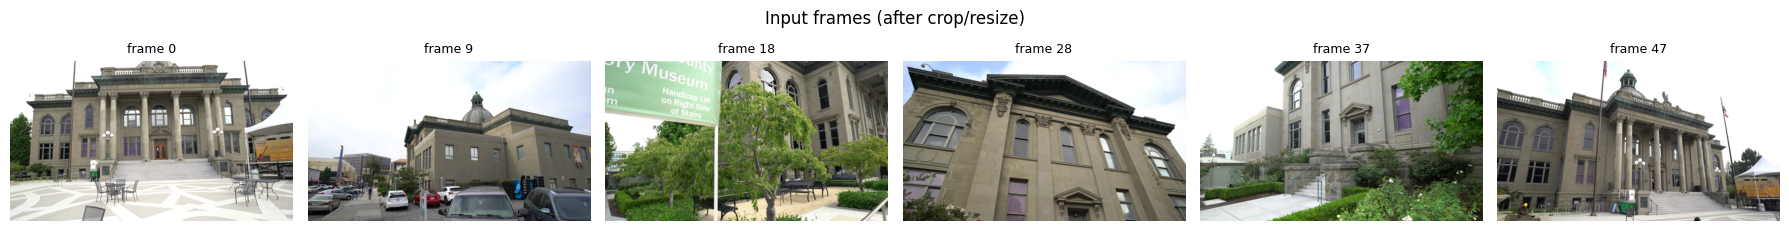


[6] Building GCTStream
pretrained_path: 


  1.16 B params  |  heads: camera=True, depth=True, point=False
  loading state dict ...
  loaded in 19s | missing=0 unexpected=0
  GPU after load: 2.62 GB allocated, 2.64 GB reserved

[7] streaming inference | frames=48 | keyframe_interval=1 | dtype=torch.float16


Streaming inference:   8%|8         | 4/48 [00:00<?, ?it/s]

  done in 22.6s  ->  2.12 FPS
  GPU peak: 8.16 GB allocated / 8.96 GB reserved
  outputs: pose_enc(1, 48, 9), depth(1, 48, 294, 518, 1), depth_conf(1, 48, 294, 518), images(1, 48, 3, 294, 518)
  kv cache: {'num_cached_blocks': 24, 'cache_memory_mb': 0.0}

[8] Decoding camera poses
  focal (px)     : 309.2   principal pt (259.0, 147.0)
  depth range    : 0.079 .. 2.328 (arbitrary but metric-consistent units)
  trajectory len : 22.332  |  extent [2.807, 0.546, 3.581]

[9] Unprojecting depth to a world point cloud
  conf threshold @ 55.0th pct = 6.287
  819,200 points kept (11.2% of all pixels, stride 2, conf>6.29)
  sanity: median ||p - cam|| / depth = 1.103 (expected ~1.00-1.15) -> OK
  scene diagonal : 3.396

[10] Plots


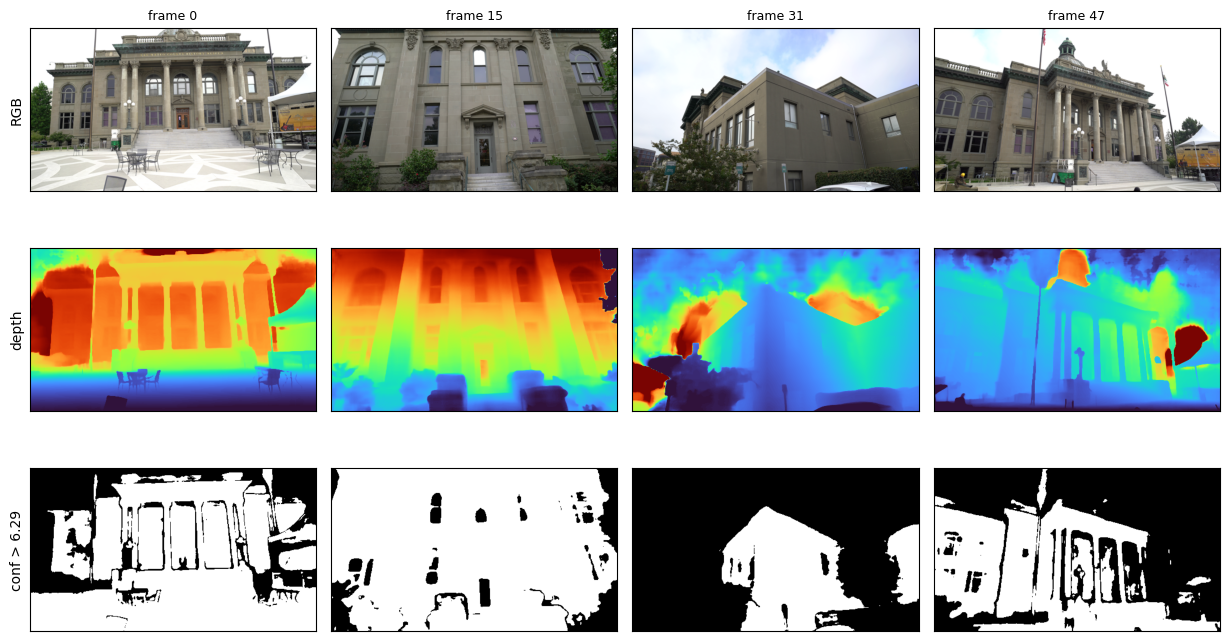

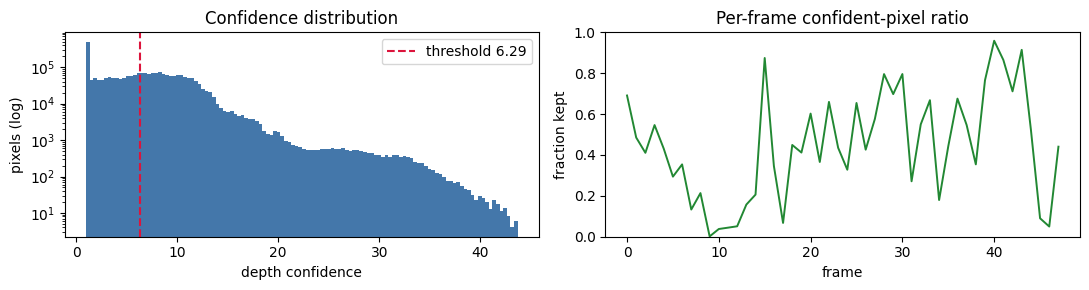

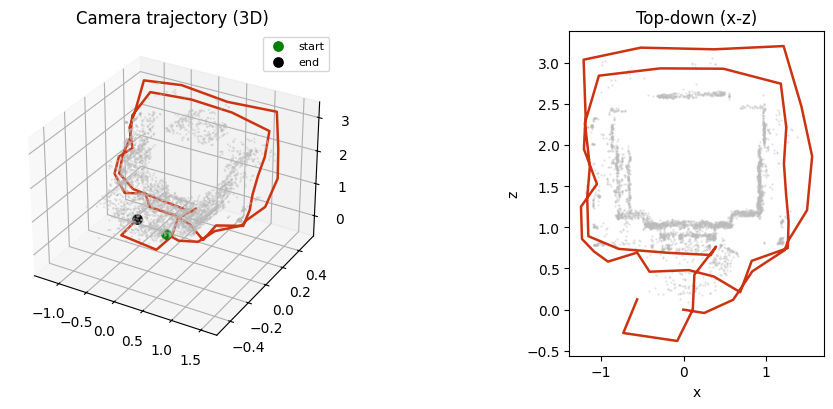

  PLY -> /content/lingbot_out/courthouse_lingbot.ply  (11.7 MB) — open in MeshLab / CloudCompare / Blender
  NPZ -> /content/lingbot_out/predictions.npz (poses + depth, fp16)
  (run `files.download(path)` in a new cell to pull a file down)

DONE. 48 frames -> 819,200 points at 2.12 FPS. Artifacts in /content/lingbot_out/

Where to go next
----------------
* More frames is the single biggest quality lever. Raise CFG['max_frames']
  until you hit OOM, then back off.
* >320 frames: the KV cache exceeds the 320-view RoPE training range. Set
  keyframe_interval (auto-computed here) rather than growing the cache.
* >3000 frames: switch CFG['mode'] to 'windowed'. window_size counts KV
  slots, not frames — with scale_frames=8 and keyframe_interval=k, one
  window covers 8 + (window_size - 8) * k actual frames.
* Outdoor scenes: pip install onnxruntime and use the repo's sky masking
  (lingbot_map.vis.apply_sky_segmentation) to drop sky points, which
  otherwise smear into the far field.
* Fla

In [ ]:
print("\n[10] Plots")

k = min(4, S)
idxs = np.linspace(0, S - 1, k).astype(int)
fig, axes = plt.subplots(3, k, figsize=(3.1 * k, 7.2))
axes = np.atleast_2d(axes)
for c, i in enumerate(idxs):
    axes[0, c].imshow(rgb[i].transpose(1, 2, 0)); axes[0, c].set_title(f"frame {i}", fontsize=9)
    d = depth[i].squeeze(-1)
    axes[1, c].imshow(d, cmap="turbo", vmin=np.percentile(d, 2), vmax=np.percentile(d, 98))
    axes[2, c].imshow(depth_conf[i] > THR, cmap="gray")
for r, lbl in enumerate(["RGB", "depth", f"conf > {THR:.2f}"]):
    axes[r, 0].set_ylabel(lbl, fontsize=10)
for a in axes.ravel():
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.savefig(f"{OUT}/depth_strip.png", dpi=110); plt.show()

plt.figure(figsize=(11, 3))
plt.subplot(1, 2, 1)
plt.hist(depth_conf[::max(1, S // 15)].ravel(), bins=120, color="#4477aa")
plt.axvline(THR, color="crimson", ls="--", label=f"threshold {THR:.2f}")
plt.yscale("log"); plt.xlabel("depth confidence"); plt.ylabel("pixels (log)")
plt.legend(); plt.title("Confidence distribution")
plt.subplot(1, 2, 2)
plt.plot([(depth_conf[i] > THR).mean() for i in range(S)], lw=1.4, color="#228833")
plt.xlabel("frame"); plt.ylabel("fraction kept"); plt.ylim(0, 1)
plt.title("Per-frame confident-pixel ratio")
plt.tight_layout(); plt.show()

fig = plt.figure(figsize=(11, 4.2))
axA = fig.add_subplot(1, 2, 1, projection="3d")
axA.plot(*cam_centers.T, color="#cc3311", lw=1.8)
axA.scatter(*cam_centers[0], s=45, c="green", label="start")
axA.scatter(*cam_centers[-1], s=45, c="black", label="end")
sub = points[np.random.choice(len(points), min(4000, len(points)), replace=False)]
axA.scatter(*sub.T, s=0.4, c="#bbbbbb", alpha=0.35)
axA.set_title("Camera trajectory (3D)"); axA.legend(fontsize=8)
axB = fig.add_subplot(1, 2, 2)
axB.plot(cam_centers[:, 0], cam_centers[:, 2], color="#cc3311", lw=1.8)
axB.scatter(sub[:, 0], sub[:, 2], s=0.4, c="#bbbbbb", alpha=0.35)
axB.set_xlabel("x"); axB.set_ylabel("z"); axB.set_aspect("equal")
axB.set_title("Top-down (x-z)")
plt.tight_layout(); plt.savefig(f"{OUT}/trajectory.png", dpi=110); plt.show()

import plotly.graph_objects as go

n_show = min(CFG["max_plot_points"], len(points))
sel = np.random.choice(len(points), n_show, replace=False)
P, C = points[sel], (colors[sel] * 255).astype(np.uint8)
inb = np.all((P >= lo) & (P <= hi), axis=1)
P, C = P[inb], C[inb]
fig = go.Figure([
    go.Scatter3d(x=P[:, 0], y=P[:, 1], z=P[:, 2], mode="markers",
                 marker=dict(size=1.2, color=[f"rgb({r},{g},{b})" for r, g, b in C]),
                 name="points", hoverinfo="skip"),
    go.Scatter3d(x=cam_centers[:, 0], y=cam_centers[:, 1], z=cam_centers[:, 2],
                 mode="lines+markers", line=dict(color="red", width=4),
                 marker=dict(size=2, color="red"), name="camera path"),
])
fig.update_layout(height=680, margin=dict(l=0, r=0, t=28, b=0),
                  title=f"LingBot-Map reconstruction — {len(P):,} of {len(points):,} points",
                  scene=dict(aspectmode="data",
                             xaxis=dict(visible=False), yaxis=dict(visible=False),
                             zaxis=dict(visible=False), bgcolor="rgb(15,15,20)"))
fig.show()

def write_ply(path, xyz, rgb01):
    rgb8 = (np.clip(rgb01, 0, 1) * 255).astype(np.uint8)
    hdr = (f"ply\nformat binary_little_endian 1.0\nelement vertex {len(xyz)}\n"
           "property float x\nproperty float y\nproperty float z\n"
           "property uchar red\nproperty uchar green\nproperty uchar blue\n"
           "end_header\n")
    dt = np.dtype([("x", "<f4"), ("y", "<f4"), ("z", "<f4"),
                   ("red", "u1"), ("green", "u1"), ("blue", "u1")])
    arr = np.empty(len(xyz), dtype=dt)
    arr["x"], arr["y"], arr["z"] = xyz[:, 0], xyz[:, 1], xyz[:, 2]
    arr["red"], arr["green"], arr["blue"] = rgb8[:, 0], rgb8[:, 1], rgb8[:, 2]
    with open(path, "wb") as f:
        f.write(hdr.encode()); f.write(arr.tobytes())

if CFG["export_ply"]:
    ply = f"{OUT}/{CFG['scene']}_lingbot.ply"
    write_ply(ply, points, colors)
    print(f"  PLY -> {ply}  ({os.path.getsize(ply)/2**20:.1f} MB) "
          "— open in MeshLab / CloudCompare / Blender")

np.savez_compressed(f"{OUT}/predictions.npz",
                    extrinsic=extrinsic, intrinsic=intrinsic,
                    cam_centers=cam_centers, depth=depth.astype(np.float16),
                    depth_conf=depth_conf.astype(np.float16))
print(f"  NPZ -> {OUT}/predictions.npz (poses + depth, fp16)")

if CFG["export_glb"]:
    sh("pip install -q trimesh", check=False)
    from lingbot_map.vis import predictions_to_glb
    wp_full = np.stack([depth_to_world_coords_points(
        depth[i].squeeze(-1), extrinsic[i], intrinsic[i])[0] for i in range(S)])
    scene = predictions_to_glb(
        {"world_points_from_depth": wp_full, "depth_conf": depth_conf,
         "images": rgb, "extrinsic": extrinsic, "intrinsic": intrinsic},
        conf_thres=CFG["conf_percentile"], prediction_mode="Predicted Depthmap")
    scene.export(f"{OUT}/{CFG['scene']}.glb")
    print(f"  GLB -> {OUT}/{CFG['scene']}.glb")

try:
    from google.colab import files
    print("  (run `files.download(path)` in a new cell to pull a file down)")
except Exception:
    pass

if CFG["launch_viser"]:
    sh("pip install -q 'viser>=0.2.23' trimesh", check=False)
    import threading
    from lingbot_map.vis import PointCloudViewer
    vis_pred = {"images": rgb, "depth": depth, "depth_conf": depth_conf,
                "extrinsic": extrinsic, "intrinsic": intrinsic}
    viewer = PointCloudViewer(pred_dict=vis_pred, port=8080,
                              vis_threshold=1.5, downsample_factor=10,
                              point_size=0.00001, use_point_map=False)
    threading.Thread(target=lambda: viewer.run(background_mode=True), daemon=True).start()
    time.sleep(3)
    from google.colab.output import serve_kernel_port_as_window
    serve_kernel_port_as_window(8080)
    print("  viser opened in a new tab (allow pop-ups)")

if CFG["run_ablation"]:
    print("\n[11b] Ablation on the first 24 frames")
    sub_imgs = images[:24]
    rows = []
    for label, kw in [("cam_iters=4, kf=1", dict(keyframe_interval=1)),
                      ("cam_iters=4, kf=2", dict(keyframe_interval=2)),
                      ("cam_iters=4, kf=4", dict(keyframe_interval=4))]:
        model.clean_kv_cache(); torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        t = time.time()
        with torch.no_grad(), torch.amp.autocast("cuda", dtype=DTYPE):
            p = model.inference_streaming(sub_imgs,
                                          num_scale_frames=CFG["num_scale_frames"],
                                          output_device=torch.device("cpu"), **kw)
        dt = time.time() - t
        e, _ = decode_poses(p["pose_enc"].float(), (H, W))
        cc = closed_form_inverse_se3(unbatch(e).cpu().numpy())[:, :3, 3]
        rows.append((label, 24 / dt, torch.cuda.max_memory_allocated() / 2**30,
                     float(np.linalg.norm(np.diff(cc, axis=0), axis=1).sum())))
        del p
    print(f"  {'setting':<20}{'FPS':>8}{'peak GB':>10}{'traj len':>11}")
    for r in rows:
        print(f"  {r[0]:<20}{r[1]:>8.2f}{r[2]:>10.2f}{r[3]:>11.3f}")
    print("  Higher keyframe_interval = less KV memory and more speed; the "
          "trajectory length drifting away from the kf=1 row is your quality cost.")

print("\n" + "=" * 78)
print(f"DONE. {S} frames -> {len(points):,} points at {S/elapsed:.2f} FPS. "
      f"Artifacts in {OUT}/")
print("=" * 78)
print(textwrap.dedent("""
    Where to go next
    ----------------
    * More frames is the single biggest quality lever. Raise CFG['max_frames']
      until you hit OOM, then back off.
    * >320 frames: the KV cache exceeds the 320-view RoPE training range. Set
      keyframe_interval (auto-computed here) rather than growing the cache.
    * >3000 frames: switch CFG['mode'] to 'windowed'. window_size counts KV
      slots, not frames — with scale_frames=8 and keyframe_interval=k, one
      window covers 8 + (window_size - 8) * k actual frames.
    * Outdoor scenes: pip install onnxruntime and use the repo's sky masking
      (lingbot_map.vis.apply_sky_segmentation) to drop sky points, which
      otherwise smear into the far field.
    * FlashInfer (use_sdpa=False) gives paged-KV attention and roughly 20 FPS at
      518x378 on a proper GPU, but JIT-compiles kernels on first call.
    * Pose collapse on long runs = state drift. Shorten the run, raise
      keyframe_interval, or move to windowed mode.
"""))